# Shape inference — Kunita flows with non-linear transitions

[Notebook 05](05_gaussian_bffg.ipynb) ran BFFG-guided MCMC under linear-Gaussian transitions, where the Theorem-14 importance weight collapses to 0. This notebook keeps the **same NumPyro driver + custom RW+pCN kernel pattern**, but **swaps the per-edge transition for a non-linear Kunita-style SDE on landmark configurations**. The result is a research-style shape-bridge MCMC, using the `hyperiax.prebuilt.bffg` `continuous_*` sweeps.

## The model

At every tree node lives a **shape** — a configuration of $n=16$ landmarks in $\mathbb{R}^2$, so the state at each node is a flat $n \cdot d = 32$-dimensional vector. Along each edge the shape evolves under a driftless SDE

$$dX_t \;=\; \sigma(X_t,\theta)\,dW_t, \qquad \sigma\sigma^\top = a(X_t,\theta),$$

where $\sigma(X,\theta)$ is given by a Laplace-2 reproducing kernel on landmark pairs (length scale $k_\sigma$ and amplitude $k_\alpha$). Leaves are observed as noisy snapshots of the terminal landmark configuration; we infer the kernel hyperparameters $\theta=(k_\alpha, k_\sigma)$ jointly with the latent bridge trajectories.

## How BFFG enters

Unlike the linear case, BFFG is **not exact** here:

- The **auxiliary process** for backward filtering is a *state-independent* linearisation: $\tilde\sigma$ is frozen at a single per-edge **anchor** point, initialised at the root shape and refined toward the BFFG posterior mean by the Algorithm 3 §7.1 iteration (`continuous_refine_anchor`).
- The closed-form *anlt* path (`continuous_bf_sweep` with `prxy_scale_fn=None, prxy_shift_fn=None`) propagates canonical messages $(\mathrm{prec}, \mathrm{ptnl}, \mathrm{log\_norm})$ up the tree under this approximation.
- The Theorem-23 importance correction $\sum \log w_v$ ([Remark 24 in the paper](https://arxiv.org/abs/2505.18239)) corrects for the discrepancy: it picks up genuine variance across noise draws, in contrast to the Theorem-14 collapse we saw in notebook 05.

The MCMC target is then

$$\pi(z, \log\theta) \;\propto\; p(z)\,p(\log\theta)\,\exp\!\bigl(\mathrm{log\_norm\_root}(\log\theta) + \sum_v \log w_v(z, \log\theta)\bigr),$$

where $\mathrm{log\_norm\_root}$ is the BFFG canonical message evaluated at the pinned root, $\log h(x_\text{root}) = c + F^\top x_\text{root} - \tfrac12 x_\text{root}^\top H x_\text{root}$. Same kernel as notebook 05: **pCN** on the noise field $z$, **RW** on the unconstrained coordinates of the positive kernel parameters.

Model and algorithm from

> van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* JMLR **26**(281), 1–51. [arXiv:2505.18239](https://arxiv.org/abs/2505.18239) — §7.1 / Theorem 23 / Remark 24.

## Outline

1. **Setup** (all inline) — tree topology, shape + kernel diffusion, true parameters and priors, schema, synthetic data, and the BFFG-guided forward map `init_continuous_tree → (continuous_bf_sweep → continuous_refine_anchor) ×N → continuous_fg_sweep`.
2. **Ground-truth bridges and a BFFG-guided draw.**
3. **The Theorem-23 importance weight** — non-zero under non-linear $\sigma$ (contrast with notebook 05's collapse).
4. **NumPyro model** wrapping the forward map.
5. **Custom `RWpCNKernel`** — pCN on the noise field $z$, RW on `(k_alpha, k_sigma)`'s unconstrained coordinates.
6. **Run the chain.**
7. **Trace plots and posterior summaries.**
8. **Multi-chain convergence** — Gelman–Rubin $\hat R$ and ESS.

Recap.

## 1. Setup

Everything is inlined so this notebook is self-contained.

### Imports + tree topology

In [1]:
%matplotlib inline
import time
from collections import namedtuple

import jax

jax.config.update("jax_enable_x64", False)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import effective_sample_size, gelman_rubin
from numpyro.infer import MCMC
from numpyro.infer.mcmc import MCMCKernel
from numpyro.infer.util import initialize_model

numpyro.set_host_device_count(3)

import hyperiax as hx
from hyperiax.prebuilt.bffg import (
    continuous_bf_sweep,
    continuous_fg_sweep,
    continuous_forward_sweep,
    continuous_refine_anchor,
    continuous_schema,
    init_continuous_tree,
)

# Depth-2 ternary tree: 1 root + 3 mid + 9 leaves = 13 nodes.
topo = hx.symmetric_topology(depth=2, degree=3)
N_NODES = topo.size
N_LEAVES = int(topo.is_leaf.sum())

print(f"tree: {N_NODES} nodes, {N_LEAVES} leaves, depth {topo.depth}")


tree: 13 nodes, 9 leaves, depth 2


/Users/vbd402/Projects/hyperiax/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Shape model — landmarks, kernel, SDE coefficients

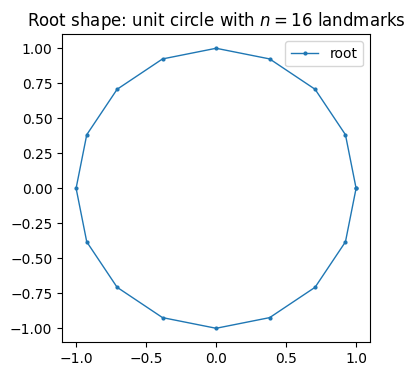

In [2]:
N_LANDMARKS, D_PER_LANDMARK = 16, 2
D = N_LANDMARKS * D_PER_LANDMARK
N_STEPS = 100
KERNEL_JITTER = 1e-6

# Root shape: closed unit circle in 2D, flattened to (n*d,).
phis = jnp.linspace(0, 2 * jnp.pi, N_LANDMARKS, endpoint=False)
ROOT_SHAPE = jnp.vstack([jnp.cos(phis), jnp.sin(phis)]).T.flatten()


def kernel_matrix(q, params):
    # Laplace-2 reproducing kernel on landmark pairs -> (n, n) covariance matrix.
    pts = q.reshape((-1, D_PER_LANDMARK))
    pair_diff = pts[:, None, :] - pts[None, :, :]
    r = jnp.sqrt(jnp.sum((pair_diff / params["k_sigma"]) ** 2, axis=-1) + 1e-8)
    return (
        params["k_alpha"]
        * (1.0 + r + (45 / 105) * r**2 + (10 / 105) * r**3 + (1 / 105) * r**4)
        * jnp.exp(-r)
    )


def diffusion_matrix(q, params):
    covar = kernel_matrix(q, params)
    covar = 0.5 * (covar + covar.T)
    jitter = KERNEL_JITTER * jnp.maximum(1.0, jnp.max(jnp.diag(covar)))
    covar = covar + jitter * jnp.eye(covar.shape[0], dtype=covar.dtype)
    return jax.scipy.linalg.cholesky(covar, lower=True, check_finite=False)


def drift_fn(t, x, params):
    return jnp.zeros(D)  # driftless: pure Kunita-style diffusion


def diffusion_fn(t, x, params):
    # Diffusion factor sigma = chol(K) kron I_d acting on the (n*d,) state.
    diffusion_mat = diffusion_matrix(x, params)
    return jnp.kron(diffusion_mat, jnp.eye(D_PER_LANDMARK))


def prxy_diffusion_fn(t, anchor, params):
    # Auxiliary diffusion, frozen at the edge's linearisation point `anchor`
    # (refined toward the posterior mean by Algorithm 3 §7.1).
    diffusion_mat = diffusion_matrix(anchor, params)
    return jnp.kron(diffusion_mat, jnp.eye(D_PER_LANDMARK))


def plot_shape(x, *, ax=None, color="C0", label=None, lw=1.0, alpha=1.0):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    pts = np.asarray(x).reshape((N_LANDMARKS, D_PER_LANDMARK))
    closed = np.vstack([pts, pts[:1]])
    ax.plot(closed[:, 0], closed[:, 1], "-o", color=color, label=label, lw=lw, ms=2, alpha=alpha)
    ax.set_aspect("equal")
    return ax


plot_shape(ROOT_SHAPE, color="C0", label="root")
plt.title(f"Root shape: unit circle with $n = {N_LANDMARKS}$ landmarks")
plt.legend()
plt.show()


### True parameters + MCMC constants

In [3]:
OBS_VAR_TRUE = 1e-3
PRIOR_CONCENTRATION = {"k_alpha": 2.0, "k_sigma": 3.0}
PRIOR_RATE = {"k_alpha": 0.5, "k_sigma": 2.0}

N_MCMC_SAMPLES = 10000
BURN_IN = 5000
N_CHAINS = 3

PCN_BETA = 0.1
RW_SCALE_BY_SITE = {"k_alpha": 0.05, "k_sigma": 0.04}
MULTICHAIN_K_ALPHA_INIT = (0.05, 0.10, 0.3)
MULTICHAIN_K_SIGMA_INIT = (0.15, 0.25, 0.5)

K_ALPHA_TRUE = 0.1
K_SIGMA_TRUE = 0.25
TRUE_PARAMS = {
    "k_alpha": jnp.array(K_ALPHA_TRUE),
    "k_sigma": jnp.array(K_SIGMA_TRUE),
}

print(f"truth: k_alpha = {K_ALPHA_TRUE}, k_sigma = {K_SIGMA_TRUE}, obs_var = {OBS_VAR_TRUE}")
print("inverse-gamma priors:")
for name in ("k_alpha", "k_sigma"):
    print(f"{name} ~ InvGamma({PRIOR_CONCENTRATION[name]}, {PRIOR_RATE[name]})")
print(f"MCMC: samples = {N_MCMC_SAMPLES}, burn-in = {BURN_IN}, chains = {N_CHAINS}")
print(f"kernel constants: pCN beta = {PCN_BETA}, RW scales = {RW_SCALE_BY_SITE}")


truth: k_alpha = 0.1, k_sigma = 0.25, obs_var = 0.001
inverse-gamma priors:
k_alpha ~ InvGamma(2.0, 0.5)
k_sigma ~ InvGamma(3.0, 2.0)
MCMC: samples = 10000, burn-in = 5000, chains = 3
kernel constants: pCN beta = 0.1, RW scales = {'k_alpha': 0.05, 'k_sigma': 0.04}


### Schema + empty tree

In [4]:
SCHEMA = continuous_schema(d=D, n_steps=N_STEPS)
empty = hx.Tree.empty(topo, SCHEMA).set(edge_len=jnp.ones(N_NODES, dtype=jnp.float32))
# Pin root at the constant unit-circle trajectory across the n_steps+1 grid.
empty = empty.at[topo.is_root].set(
    vals=jnp.broadcast_to(ROOT_SHAPE, (N_STEPS + 1, D))
)

print(f"schema fields: {list(SCHEMA.keys())}")
print(f"state dim per node = {D};  noise per node = (n_steps, D) = ({N_STEPS}, {D})")


schema fields: ['edge_len', 'vals', 'zs', 'ptnls', 'precs', 'ptnl_v', 'prec_v', 'anchor', 'anchor_pa', 'log_norm', 'log_corr']
state dim per node = 32;  noise per node = (n_steps, D) = (100, 32)


### Synthetic data — forward simulation under the truth

`continuous_forward_sweep` walks root -> leaves drawing each bridge under the true `(drift_fn, diffusion_fn)` via Euler-Maruyama. We take the terminal landmark configuration at every leaf and corrupt it with iid Gaussian noise of variance $\tau^2$.

In [5]:
_sweep_forward = continuous_forward_sweep(N_STEPS, drift_fn, diffusion_fn)

k_path, k_obs = jax.random.split(jax.random.PRNGKey(202605), 2)
_gt = empty.set(zs=jax.random.normal(k_path, (N_NODES, N_STEPS, D)))
_gt = _sweep_forward(_gt, params=TRUE_PARAMS)

leaf_truth = _gt.vals[topo.is_leaf, -1]
_obs_noise = jnp.sqrt(OBS_VAR_TRUE) * jax.random.normal(k_obs, leaf_truth.shape)
leaf_obs = leaf_truth + _obs_noise   # (N_LEAVES, D)
print(f"leaf_obs.shape = {leaf_obs.shape}")


leaf_obs.shape = (9, 32)


### BFFG-guided forward map (Algorithm 3 with iterative linearisation)

Four sweeps from `hyperiax.prebuilt.bffg.continuous_*`:

- **`init_continuous_tree`** — seeds the leaf vertex messages $(H_\ell = I/\tau^2,\, F_\ell = y_\ell/\tau^2,\, c_\ell = -\tfrac{d}{2}\log 2\pi\tau^2 - \tfrac{1}{2\tau^2}\,y_\ell^\top y_\ell)$, pins the root trajectory, and broadcasts an initial `anchor` (root shape) to every node.
- **`continuous_bf_sweep`** — backward filter; evaluates $\tilde\sigma$ at each edge's current `anchor`. With `prxy_scale_fn=prxy_shift_fn=None` it dispatches to the closed-form *anlt* path with the matching c-update.
- **`continuous_refine_anchor`** — `@down` sweep that updates each non-root node's `anchor` to the BFFG-implied posterior mean $\mathrm{prec}^{-1}\mathrm{ptnl}$. This is Algorithm 3 §7.1 — iterating `bf → refine` 3–10 times converges the linearisation point to the per-edge posterior mean, which is what keeps BFFG-MCMC accurate on the non-linear SDE.
- **`continuous_fg_sweep`** — guided forward (Euler-Maruyama under the BFFG drift), accumulating the per-edge Theorem-23 correction into `log_corr`.

The map $(z, \log\theta) \mapsto (\mathrm{bridges},\,\sum \log w,\,\mathrm{log\_norm\_root})$ is pure and `jit`-compilable.

In [6]:
N_LIN_ITERS = 3   # 3-10 typically; the iteration converges geometrically.

bf_sweep = continuous_bf_sweep(N_STEPS, None, None, prxy_diffusion_fn)
refine = continuous_refine_anchor()
fg_sweep = continuous_fg_sweep(
    N_STEPS, drift_fn, diffusion_fn, None, None, prxy_diffusion_fn
)


@jax.jit
def bffg_guided_forward(z, theta, obs_var=OBS_VAR_TRUE):
    """init -> (bf_sweep -> refine_anchor)^N -> guided forward (Algorithm 3).

    z is the flat (N_NODES*N_STEPS*D,) driving noise; theta is
    [k_alpha, k_sigma] on the positive scale. Returns (bridges, sum_log_corr, log_h_root),
    the last being the BFFG canonical message c + F.x - 0.5 x.H x at the root.
    """
    params = {
        "k_alpha": theta[0],
        "k_sigma": theta[1],
    }
    t = init_continuous_tree(
        empty,
        leaf_obs,
        obs_var=obs_var,
        d=D,
        n_steps=N_STEPS,
        root_val=ROOT_SHAPE,
        anchor_init=ROOT_SHAPE,
    )
    # Refine the per-edge linearisation anchor toward the posterior mean.
    for _ in range(N_LIN_ITERS):
        t = bf_sweep(t, params=params)
        t = refine(t, params=params)
    t = t.set(zs=z.reshape((N_NODES, N_STEPS, D)))
    t = fg_sweep(t, params=params)

    c_root = t.log_norm[0]
    f_root = t.ptnl_v[0]
    h_root = t.prec_v[0]
    log_h_root = c_root + f_root @ ROOT_SHAPE - 0.5 * ROOT_SHAPE @ h_root @ ROOT_SHAPE
    return t.vals, t.log_corr.sum(), log_h_root


## 2. Ground-truth bridges and a BFFG-guided draw

Sanity check: run the forward sweep under the truth (giving prior-distributed bridges), then run one BFFG cycle (which uses the leaf observations to guide the bridges). The guided draw's leaf terminals should land within ≈$\sqrt{\tau^2}$ of the observed shapes.

In [7]:
# Reuse the existing _gt computed above for the ground truth.
ground_truth_vals = _gt.vals

z0 = jax.random.normal(jax.random.PRNGKey(0), (N_NODES * N_STEPS * D,), )
guided_vals, guided_sum_log_corr, guided_log_norm = bffg_guided_forward(
    z0, jnp.array([K_ALPHA_TRUE, K_SIGMA_TRUE], )
)

rmse = float(jnp.sqrt(jnp.mean((guided_vals[topo.is_leaf, -1] - leaf_obs) ** 2)))
print(f"BFFG-guided leaf-terminal RMSE vs leaf_obs: {rmse:.4f}  (target approx sqrt(obs_var) = {jnp.sqrt(OBS_VAR_TRUE):.4f})")
print(f"BFFG cycle sum log_corr at θ_true (one draw): {float(guided_sum_log_corr):.3f}")
print(f"log_norm at root (= BFFG estimate of log p(y | θ_true)): {float(guided_log_norm):.3f}")


BFFG-guided leaf-terminal RMSE vs leaf_obs: 0.0933  (target approx sqrt(obs_var) = 0.0316)
BFFG cycle sum log_corr at θ_true (one draw): -759.758
log_norm at root (= BFFG estimate of log p(y | θ_true)): 94.751


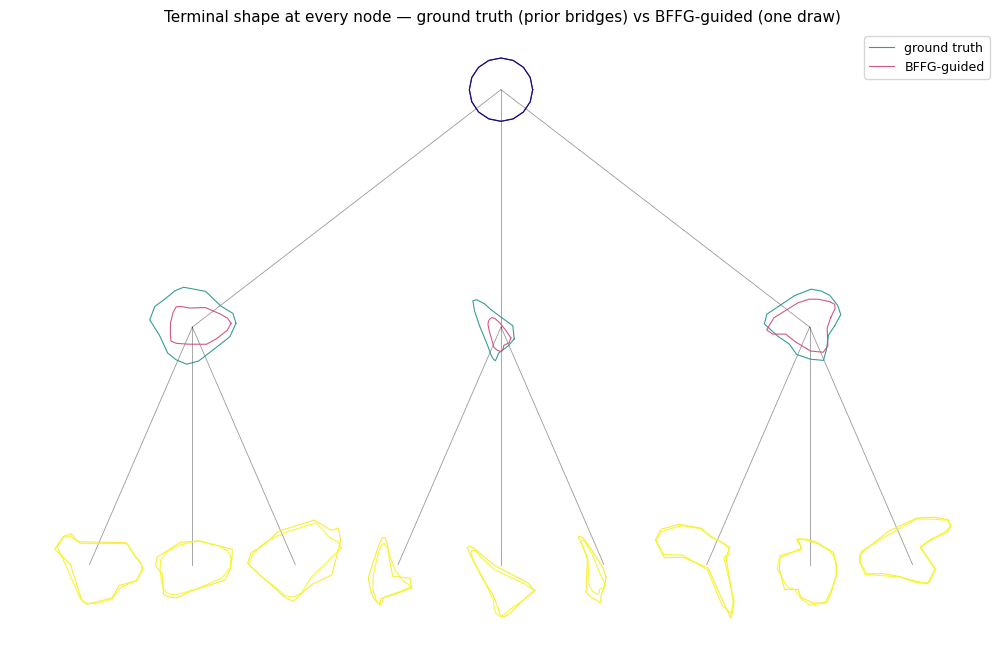

In [8]:
def _dfs_x_positions(topo):
    xs = np.zeros(topo.size)
    next_leaf = [0]
    n_leaves = int(topo.is_leaf.sum())
    def visit(node):
        if topo.is_leaf[node]:
            xs[node] = next_leaf[0] / max(1, n_leaves - 1); next_leaf[0] += 1
            return xs[node]
        children = [i for i in range(1, topo.size) if int(topo.parents[i]) == int(node)]
        cx = [visit(c) for c in children]
        xs[node] = float(np.mean(cx)); return xs[node]
    visit(0)
    return xs


def plot_tree_shapes(values_dict, title=None, scaling=0.4, figsize=(18, 8)):
    pos = np.zeros((topo.size, 2))
    pos[:, 0] = _dfs_x_positions(topo) * (topo.size * 0.8)
    pos[:, 1] = -np.asarray(topo.node_depths) * 3.0
    cmaps = ["viridis", "plasma", "inferno"]
    fig, ax = plt.subplots(figsize=figsize)
    for i in range(1, topo.size):
        p = int(topo.parents[i])
        ax.plot([pos[p, 0], pos[i, 0]], [pos[p, 1], pos[i, 1]], "k-", lw=0.6, alpha=0.4, zorder=1)
    for ci, (key, vals) in enumerate(values_dict.items()):
        cmap = plt.get_cmap(cmaps[ci % len(cmaps)])
        for i in range(topo.size):
            v = np.asarray(vals[i])
            terminal = v[-1] if v.ndim == 2 else v
            pts = terminal.reshape((N_LANDMARKS, D_PER_LANDMARK))
            closed = np.vstack([pts, pts[:1]])
            c = cmap(int(topo.node_depths[i]) / max(1, topo.depth))
            ax.plot(closed[:, 0] * scaling + pos[i, 0],
                    closed[:, 1] * scaling + pos[i, 1],
                    "-", color=c, lw=0.8, alpha=0.9, zorder=2,
                    label=key if i == 1 else None)
    if title: ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.set_aspect("equal"); ax.set_axis_off()
    return fig, ax


plot_tree_shapes(
    {"ground truth": ground_truth_vals, "BFFG-guided": guided_vals},
    title="Terminal shape at every node — ground truth (prior bridges) vs BFFG-guided (one draw)"
)
plt.show()


## 3. The Theorem-23 importance weight is no longer 0

Notebook 05 verified $\sum \log w \equiv 0$ across noise draws (Theorem-14 collapse for linear-Gaussian transitions). Here the **true** SDE has state-dependent diffusion $\sigma(X)$ while the **auxiliary** uses $\sigma(\text{root})$ — so the Theorem-23 correction has work to do, and we see real variation in $\sum \log w$ across noise draws.

50 noise draws at θ_true:
  sum log_corr — mean = -485.211, std = 175.433
  (in notebook 05's linear case this would be identically 0)


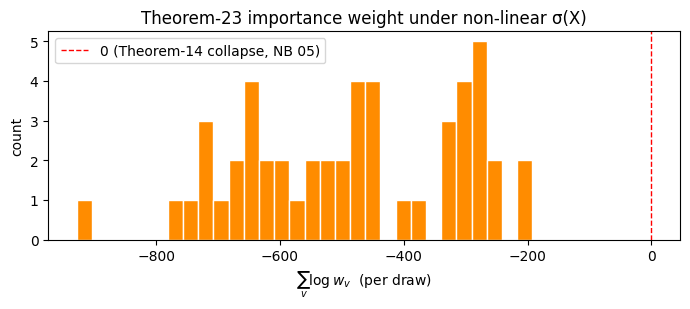

In [9]:
keys = jax.random.split(jax.random.PRNGKey(11), 50)
theta_true = jnp.array([K_ALPHA_TRUE, K_SIGMA_TRUE], dtype=jnp.float32)
sums = []
for k in keys:
    z = jax.random.normal(k, (N_NODES * N_STEPS * D,), dtype=jnp.float32)
    _, slc, _ = bffg_guided_forward(z, theta_true)
    sums.append(float(slc))
sums = np.asarray(sums)

print(f"50 noise draws at θ_true:")
print(f"  sum log_corr — mean = {sums.mean():+8.3f}, std = {sums.std():.3f}")
print(f"  (in notebook 05's linear case this would be identically 0)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(sums, bins=30, color="darkorange", edgecolor="white")
ax.axvline(0, color="r", ls="--", lw=1, label="0 (Theorem-14 collapse, NB 05)")
ax.set_xlabel(r"$\sum_v \log w_v$  (per draw)")
ax.set_ylabel("count")
ax.set_title("Theorem-23 importance weight under non-linear σ(X)")
ax.legend(); plt.tight_layout(); plt.show()


## 4. NumPyro model

Three sites:

- $k_\alpha$, $k_\sigma$ with weakly-informative inverse-gamma priors — $\mathrm{InvGamma}(3.0,\,0.4)$ and $\mathrm{InvGamma}(3.0,\,1.0)$, both on the positive scale.
- $z$ — the per-step Brownian-noise field flattened to one vector of length $N_\text{nodes} \cdot N_\text{steps} \cdot D$.

The BFFG-implied log-density goes in via `numpyro.factor`:

$$\text{factor}_\text{bffg} \;=\; \mathrm{log\_norm\_root}(\theta) \;+\; \sum_v \log w_v(z, \theta).$$

`log_norm_root` is the BFFG estimate of the marginal log-likelihood, $\log h(x_\text{root})$, read off the canonical message at the pinned root.

In [10]:
N_Z = N_NODES * N_STEPS * D
print(f"noise dimension: {N_Z}")


def model():
    k_alpha = numpyro.sample(
        "k_alpha", dist.InverseGamma(PRIOR_CONCENTRATION["k_alpha"], PRIOR_RATE["k_alpha"])
    )
    k_sigma = numpyro.sample(
        "k_sigma", dist.InverseGamma(PRIOR_CONCENTRATION["k_sigma"], PRIOR_RATE["k_sigma"])
    )
    z = numpyro.sample("z", dist.Normal(jnp.zeros(N_Z), 1.0).to_event(1))
    theta = jnp.stack([k_alpha, k_sigma])
    _, sum_log_corr, log_norm_root = bffg_guided_forward(z, theta)
    numpyro.factor("bffg", log_norm_root + sum_log_corr)


def initialize_numpyro(rng_key=jax.random.PRNGKey(0)):
    return initialize_model(rng_key, model, validate_grad=False)


mi = initialize_numpyro()
potential_fn = mi.potential_fn
# initialize_model's potential_fn works in unconstrained space; positive sites use log coordinates.
init_u = {
    "k_alpha": jnp.log(jnp.array(K_ALPHA_TRUE)),
    "k_sigma": jnp.log(jnp.array(K_SIGMA_TRUE)),
    "z": jnp.zeros(N_Z),
}
print(f"U at (θ_true, z=0) = {float(potential_fn(init_u)):.4f}")


noise dimension: 41600
U at (θ_true, z=0) = 38265.2969


## 5. Custom `RWpCNKernel` — with proposal diagnostics

Two-block Metropolis-within-Gibbs:

- **pCN block** on `z`: $z' = \sqrt{1-\beta^2}\,z + \beta\,\varepsilon$, with $\varepsilon$, reversible w.r.t. $\mathcal{N}(0, I)$. One-line correction subtracts the $z$-prior delta that `potential_fn` bakes in.
- **RW block** on NumPyro's unconstrained coordinates for $(k_\alpha, k_\sigma)$: symmetric Gaussian random walk, with a separate scale per parameter.

The extra fields `pcn_log_alpha` and `pcn_delta_potential` record the pCN proposal quality before the accept/reject update.


In [11]:
RWpCNState = namedtuple(
    "RWpCNState",
    ["u", "potential_energy", "accept", "pcn_log_alpha", "pcn_delta_potential", "rng_key"],
)


def _std_normal_logpdf(x):
    return -0.5 * jnp.sum(x**2)


class RWpCNKernel(MCMCKernel):
    sample_field = "u"

    def __init__(
        self,
        potential_fn,
        *,
        pcn_beta,
        rw_scale,
        noise_site="z",
        param_sites=("k_alpha", "k_sigma"),
        postprocess_fn=None,
    ):
        self._potential_fn = potential_fn
        self._pcn_beta = pcn_beta
        self._noise_site = noise_site
        self._param_sites = tuple(param_sites)
        if isinstance(rw_scale, dict):
            self._rw_scale_by_site = {site: float(rw_scale[site]) for site in self._param_sites}
        else:
            self._rw_scale_by_site = {site: float(rw_scale) for site in self._param_sites}
        self._postprocess_fn = postprocess_fn or (lambda x: x)

    def init(self, rng_key, num_warmup, init_params, model_args, model_kwargs):
        if init_params is None:
            raise ValueError("RWpCNKernel needs explicit init_params (a dict per site).")
        return RWpCNState(
            init_params,
            self._potential_fn(init_params),
            jnp.zeros(2),
            jnp.array(0.0),
            jnp.array(0.0),
            rng_key,
        )

    def postprocess_fn(self, model_args, model_kwargs):
        return self._postprocess_fn

    def sample(self, state, model_args, model_kwargs):
        u = dict(state.u)
        u_energy = state.potential_energy
        k_pcn, k_pcn_acc, k_rw, k_rw_acc, k_next = jax.random.split(state.rng_key, 5)

        # pCN on noise (params fixed); subtract z-prior delta since U bakes it in.
        z = u[self._noise_site]
        z_prop = jnp.sqrt(1 - self._pcn_beta**2) * z + self._pcn_beta * jax.random.normal(
            k_pcn, z.shape
        )
        prop_energy = self._potential_fn({**u, self._noise_site: z_prop})
        pcn_delta_potential = prop_energy - u_energy
        pcn_log_alpha = -pcn_delta_potential - (_std_normal_logpdf(z_prop) - _std_normal_logpdf(z))
        log_alpha = pcn_log_alpha
        acc_z = jnp.log(jax.random.uniform(k_pcn_acc)) < log_alpha
        u[self._noise_site] = jnp.where(acc_z, z_prop, z)
        u_energy = jnp.where(acc_z, prop_energy, u_energy)

        # RW on each unconstrained param site (noise fixed); symmetric, no correction.
        rw_keys = jax.random.split(k_rw, len(self._param_sites))
        u_prop = dict(u)
        for site, key in zip(self._param_sites, rw_keys):
            scale = self._rw_scale_by_site[site]
            u_prop[site] = u[site] + scale * jax.random.normal(key, u[site].shape)
        prop_energy = self._potential_fn(u_prop)
        acc_th = jnp.log(jax.random.uniform(k_rw_acc)) < -(prop_energy - u_energy)
        for site in self._param_sites:
            u[site] = jnp.where(acc_th, u_prop[site], u[site])
        u_energy = jnp.where(acc_th, prop_energy, u_energy)

        accept = jnp.array([acc_z, acc_th], dtype=state.accept.dtype)
        return RWpCNState(u, u_energy, accept, pcn_log_alpha, pcn_delta_potential, k_next)


## 6. Run the chain

Single-chain debugging starts from a deliberately non-truth point, while the RW block explores $	heta$ and pCN moves the noise field $z$. For a non-linear SDE the RW acceptance is driven by the *combined* movement of `log_norm_root` and $\sum \log w$, which depends on both the latent bridge and the parameters — so the chain is genuinely informative.

We set `num_warmup=0`: this fixed kernel does no warmup adaptation, and NumPyro drops warmup draws from `get_samples()`, so a non-zero warmup would silently hide the convergence transient. We keep the full chain and burn in during post-processing instead.


In [12]:
# num_warmup=0: NumPyro drops warmup draws from get_samples() and this fixed
# kernel does no warmup adaptation, so a non-zero warmup would hide the
# convergence transient. Keep the full chain; burn in during post-processing.
N_WARMUP = 0
N_SAMPLES = N_MCMC_SAMPLES

kernel = RWpCNKernel(
    potential_fn,
    pcn_beta=PCN_BETA,
    rw_scale=RW_SCALE_BY_SITE,
    postprocess_fn=mi.postprocess_fn,
)
# init_params are unconstrained coordinates; postprocess_fn maps saved samples back to k-space.
init_u = {
    "k_alpha": jnp.log(jnp.array(0.2)),
    "k_sigma": jnp.log(jnp.array(0.5)),
    "z": jax.random.normal(jax.random.PRNGKey(33), (N_Z,)),
}

mc = MCMC(
    kernel,
    num_warmup=N_WARMUP,
    num_samples=N_SAMPLES,
    num_chains=1,
    progress_bar=False,
)
t0 = time.perf_counter()
mc.run(
    jax.random.PRNGKey(7),
    init_params=init_u,
    extra_fields=("accept", "potential_energy", "pcn_log_alpha", "pcn_delta_potential"),
)
samples = mc.get_samples()
extra_fields = mc.get_extra_fields()
jax.block_until_ready((samples, extra_fields))
elapsed = time.perf_counter() - t0

acc = np.asarray(extra_fields["accept"])
potential_energy = np.asarray(extra_fields["potential_energy"])
pcn_log_alpha = np.asarray(extra_fields["pcn_log_alpha"])
pcn_delta_potential = np.asarray(extra_fields["pcn_delta_potential"])
k_alpha = np.asarray(samples["k_alpha"])
k_sigma = np.asarray(samples["k_sigma"])

print(f"RW/pCN: {elapsed:.1f}s   {N_SAMPLES} samples")
print(f"  acc pCN = {acc[..., 0].mean():.4f}")
print(f"  acc RW  = {acc[..., 1].mean():.4f}  (target band 0.20-0.55)")
print(f"  mean potential U (incl. z-prior) = {potential_energy.mean():.1f}")


RW/pCN: 303.6s   10000 samples
  acc pCN = 0.2210
  acc RW  = 0.2800  (target band 0.20-0.55)
  mean potential U (incl. z-prior) = 58998.5


## 7. Trace plots and posterior summaries

NumPyro's `potential_energy` is $U = -\log$ joint and bakes in the standard-normal $z$-prior, whose normaliser $\tfrac12 N_Z\log 2\pi$ (here $\sim\!4\times10^4$) and quadratic $\tfrac12\lVert z\rVert^2$ dwarf the BFFG log-likelihood and have the wrong sign for a "target". The pCN block cancels that prior in its acceptance, so we add it back to recover the meaningful log-target $\log p(y\mid\theta) + \log p(\theta)$ — an $O(10^2)$ quantity with a clear convergence trend.

Posterior summaries (after burn-in = 5000):
  k_alpha: mean=0.112 +/- 0.015, truth = 0.1
  k_sigma: mean=0.262 +/- 0.008, truth = 0.25
  log target: start=-5431.8 -> tail mean=285.5
  pCN log alpha: mean=-4.10, q10/50/90=[-8.01757812 -3.97070312 -0.3125    ]
  pCN delta U proposal: mean=2.0, q10/50/90=[-24.3203125    1.7734375   28.37539063]


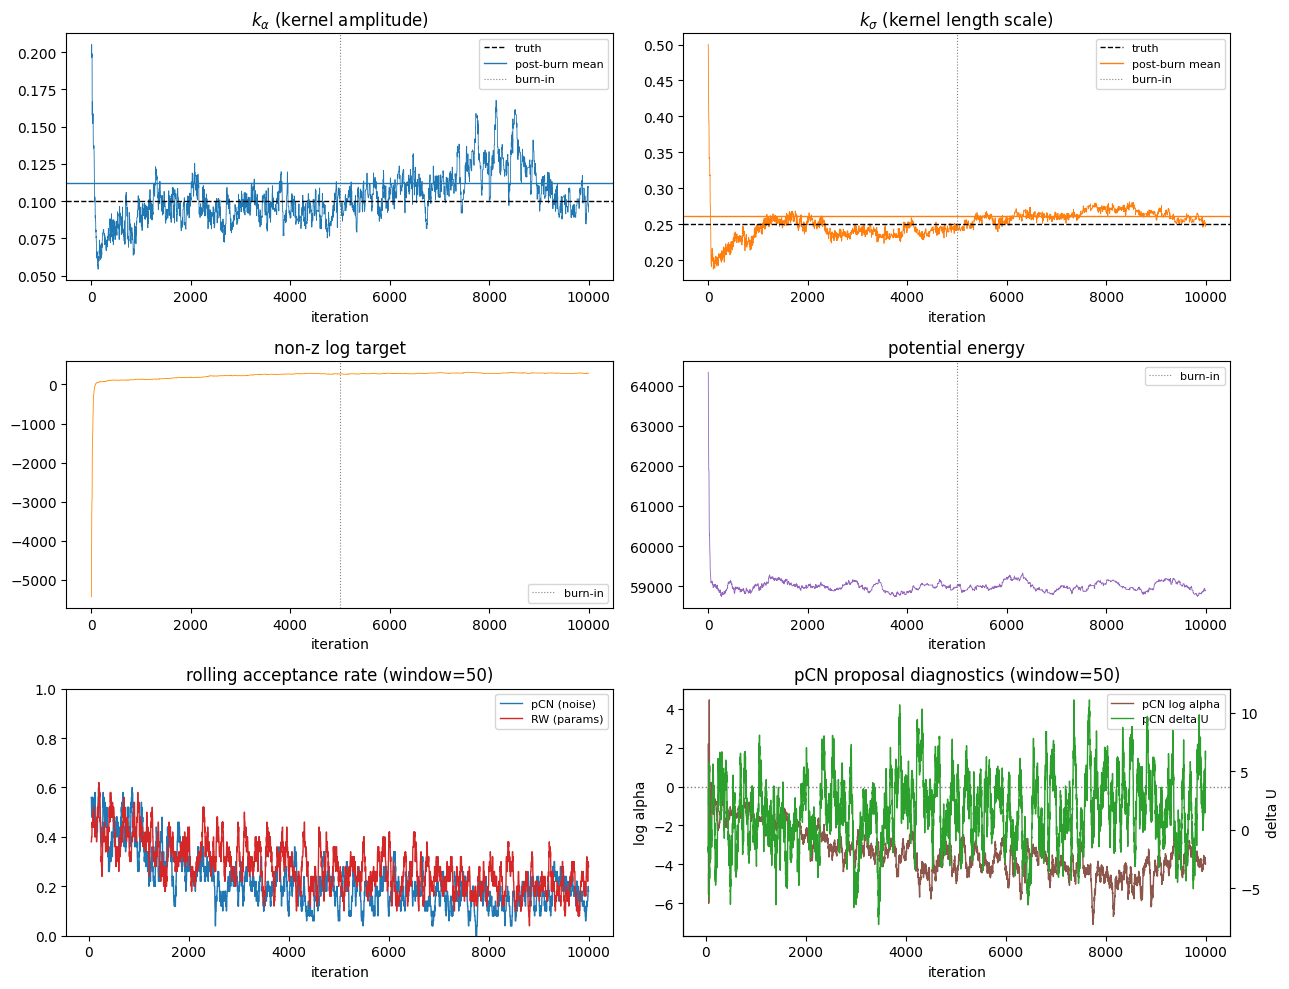

In [13]:
burn = BURN_IN
window = 50


def _rolling_mean(values, window):
    values = np.asarray(values)
    window = min(window, len(values))
    if window <= 1:
        return np.arange(len(values)), values
    return np.arange(window - 1, len(values)), np.convolve(values, np.ones(window) / window, mode="valid")


def _post_burn_or_all(values, burn, *, sample_axis=0):
    values = np.asarray(values)
    if burn < values.shape[sample_axis]:
        slices = [slice(None)] * values.ndim
        slices[sample_axis] = slice(burn, None)
        return values[tuple(slices)]
    return values


k_alpha_post = _post_burn_or_all(k_alpha, burn)
k_sigma_post = _post_burn_or_all(k_sigma, burn)
pcn_log_alpha_post = _post_burn_or_all(pcn_log_alpha, burn)
pcn_delta_potential_post = _post_burn_or_all(pcn_delta_potential, burn)

# Reconstruct the meaningful log-target from the saved trace. U = -log joint
# bakes in the z-prior (constant ½·N_Z·log(2π) ~4e4 plus a drifting ½Σz²), which
# buries the BFFG log-likelihood. pCN cancels that prior in its acceptance, so
# adding it back is exact and recovers log p(y | θ) + log p(θ) ~ O(1e2).
z_arr = np.asarray(samples["z"])
N_Z_ = z_arr.shape[-1]
z_sq = np.einsum("ij,ij->i", z_arr, z_arr)                 # Σz² per draw
log_target = -potential_energy + 0.5 * z_sq + 0.5 * N_Z_ * np.log(2.0 * np.pi)
log_target_post = _post_burn_or_all(log_target, burn)

print(f"Posterior summaries (after burn-in = {burn}):")
for name, post, truth in [
    ("k_alpha", k_alpha_post, K_ALPHA_TRUE),
    ("k_sigma", k_sigma_post, K_SIGMA_TRUE),
]:
    print(f"  {name}: mean={post.mean():.3f} +/- {post.std():.3f}, truth = {truth}")
print(f"  log target: start={log_target[0]:.1f} -> tail mean={log_target_post.mean():.1f}")
print(
    "  pCN log alpha: "
    f"mean={pcn_log_alpha_post.mean():.2f}, "
    f"q10/50/90={np.quantile(pcn_log_alpha_post, [0.1, 0.5, 0.9])}"
)
print(
    "  pCN delta U proposal: "
    f"mean={pcn_delta_potential_post.mean():.1f}, "
    f"q10/50/90={np.quantile(pcn_delta_potential_post, [0.1, 0.5, 0.9])}"
)

fig, axes = plt.subplots(3, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.plot(k_alpha, lw=0.6, color="C0")
ax.axhline(K_ALPHA_TRUE, ls="--", color="k", lw=1, label="truth")
ax.axhline(k_alpha_post.mean(), ls="-", color="C0", lw=1, label="post-burn mean")
ax.axvline(burn, ls=":", color="gray", lw=0.8, label="burn-in")
ax.set_title(r"$k_\alpha$ (kernel amplitude)")
ax.set_xlabel("iteration")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(k_sigma, lw=0.6, color="C1")
ax.axhline(K_SIGMA_TRUE, ls="--", color="k", lw=1, label="truth")
ax.axhline(k_sigma_post.mean(), ls="-", color="C1", lw=1, label="post-burn mean")
ax.axvline(burn, ls=":", color="gray", lw=0.8, label="burn-in")
ax.set_title(r"$k_\sigma$ (kernel length scale)")
ax.set_xlabel("iteration")
ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(log_target, lw=0.6, color="darkorange")
ax.axvline(burn, ls=":", color="gray", lw=0.8, label="burn-in")
ax.set_title("non-z log target")
ax.set_xlabel("iteration")
ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(potential_energy, lw=0.6, color="C4")
ax.axvline(burn, ls=":", color="gray", lw=0.8, label="burn-in")
ax.set_title("potential energy")
ax.set_xlabel("iteration")
ax.legend(fontsize=8)

ax = axes[2, 0]
xs, acc_pcn = _rolling_mean(acc[:, 0], window)
_, acc_rw = _rolling_mean(acc[:, 1], window)
ax.plot(xs, acc_pcn, lw=1, color="C0", label="pCN (noise)")
ax.plot(xs, acc_rw, lw=1, color="C3", label="RW (params)")
ax.set_title(f"rolling acceptance rate (window={window})")
ax.set_xlabel("iteration")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

ax = axes[2, 1]
xs, rolling_log_alpha = _rolling_mean(pcn_log_alpha, window)
_, rolling_delta_u = _rolling_mean(pcn_delta_potential, window)
line_log_alpha = ax.plot(xs, rolling_log_alpha, lw=1, color="C5", label="pCN log alpha")
ax.axhline(0.0, ls=":", color="gray", lw=1)
ax.set_title(f"pCN proposal diagnostics (window={window})")
ax.set_xlabel("iteration")
ax.set_ylabel("log alpha")

ax_delta = ax.twinx()
line_delta_u = ax_delta.plot(xs, rolling_delta_u, lw=1, color="C2", label="pCN delta U")
ax_delta.set_ylabel("delta U")

lines = line_log_alpha + line_delta_u
ax.legend(lines, [line.get_label() for line in lines], fontsize=8)

plt.tight_layout()
plt.show()


## 8. Multi-chain convergence — Gelman–Rubin $\hat R$

A single well-mixing chain is necessary but not sufficient. We run several chains from **overdispersed** starts and check they agree, via the Gelman–Rubin $\hat R$ (between- vs within-chain variance) and the effective sample size.

`num_chains` only sets the count; *how* they run is `chain_method` — and none of the options is OS multi-threading:

- `"vectorized"` (`jax.vmap`) hands the kernel a *batched* state with a leading chain axis, so the kernel must be written to handle it. NumPyro's built-in NUTS/HMC are; our hand-written `RWpCNKernel` calls `potential_fn` on whatever state it gets, so a batched state breaks it.
- `"parallel"` (`jax.pmap`) runs one chain per XLA device — needs `num_chains` devices. The setup cell calls `numpyro.set_host_device_count(N_CHAINS)` so CPU can expose enough devices before the chain is run.
- `"sequential"` runs the chains through a compiled `lax.map` over the chain axis; each chain sees a single-chain state, so the custom kernel works unchanged on one device.

We use **`"parallel"`** here to match the debug script. If device setup is inconvenient, change `CHAIN_METHOD` below to `"sequential"` without changing the statistical target.

NumPyro keeps every chain's full trace — including the large noise field $z$ — in memory, so drop `N_CHAINS` or `N_SAMPLES` if it gets tight.


In [14]:
CHAIN_METHOD = "parallel"

# Overdispersed per-chain starts bracketing the truth (unconstrained space) plus an
# independent noise field per chain. Each init_params leaf carries a leading
# (N_CHAINS,) axis; vectorized/parallel chains slice along it.
ka_init = jnp.log(jnp.array(MULTICHAIN_K_ALPHA_INIT))  # truth 0.10
ks_init = jnp.log(jnp.array(MULTICHAIN_K_SIGMA_INIT))  # truth 0.25
z_keys = jax.random.split(jax.random.PRNGKey(2024), N_CHAINS)
z_init = jax.vmap(lambda k: jax.random.normal(k, (N_Z,)))(z_keys)
init_chains = {"k_alpha": ka_init, "k_sigma": ks_init, "z": z_init}

mc_multi = MCMC(
    RWpCNKernel(
        potential_fn,
        pcn_beta=PCN_BETA,
        rw_scale=RW_SCALE_BY_SITE,
        postprocess_fn=mi.postprocess_fn,
    ),
    num_warmup=0,
    num_samples=N_SAMPLES,
    num_chains=N_CHAINS,
    chain_method=CHAIN_METHOD,
    progress_bar=False,
)
t0 = time.perf_counter()
mc_multi.run(
    jax.random.PRNGKey(404),
    init_params=init_chains,
    extra_fields=("accept", "potential_energy", "pcn_log_alpha", "pcn_delta_potential"),
)
samples_mc = mc_multi.get_samples(group_by_chain=True)            # leaves: (N_CHAINS, N_SAMPLES, ...)
extra_fields_mc = mc_multi.get_extra_fields(group_by_chain=True)
jax.block_until_ready((samples_mc, extra_fields_mc))
elapsed_multi = time.perf_counter() - t0
print(f"{N_CHAINS} chains x {N_SAMPLES} samples ({CHAIN_METHOD}): {elapsed_multi:.1f}s")

acc_mc = np.asarray(extra_fields_mc["accept"])  # (N_CHAINS, N_SAMPLES, 2)
k_alpha_c = np.asarray(samples_mc["k_alpha"])  # (N_CHAINS, N_SAMPLES)
k_sigma_c = np.asarray(samples_mc["k_sigma"])
log_ka_c = np.log(k_alpha_c)
log_ks_c = np.log(k_sigma_c)
for c in range(N_CHAINS):
    print(f"  chain {c}: acc pCN={acc_mc[c, :, 0].mean():.3f}  acc RW={acc_mc[c, :, 1].mean():.3f}")


3 chains x 10000 samples (parallel): 386.7s
  chain 0: acc pCN=0.281  acc RW=0.342
  chain 1: acc pCN=0.252  acc RW=0.358
  chain 2: acc pCN=0.218  acc RW=0.298


After burn-in = 5000  (3 chains x 5000 draws):
  k_alpha: mean=0.102 +/- 0.012, R-hat=1.1254 (NOT converged (run longer)), ESS=16
  k_sigma: mean=0.251 +/- 0.012, R-hat=1.2983 (NOT converged (run longer)), ESS=4


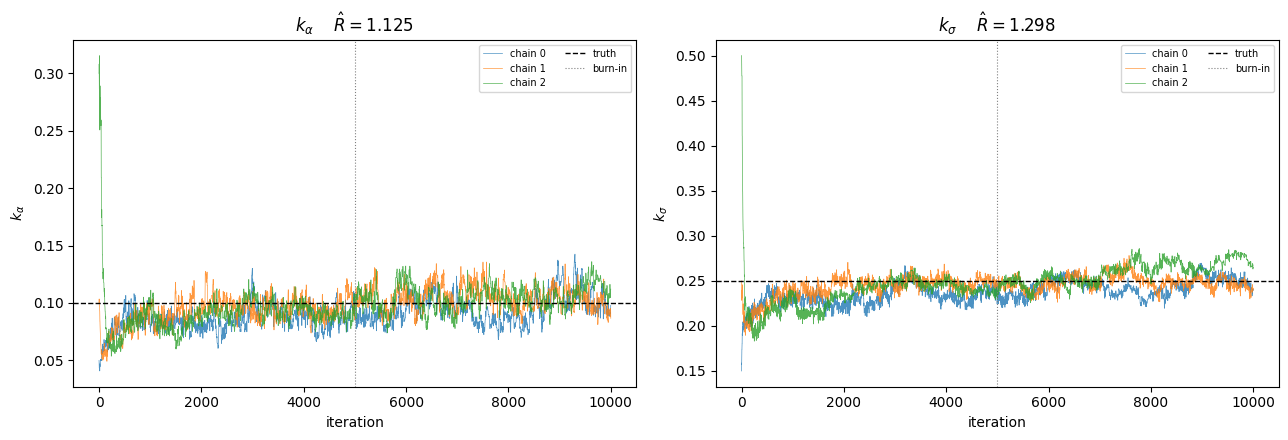

In [16]:
burn = BURN_IN

# Gelman-Rubin R-hat and ESS on the post-burn-in chains, using log parameters
# for scale-stable diagnostics. numpyro's diagnostics take a (num_chains, num_samples) array.
log_ka_tail = _post_burn_or_all(log_ka_c, burn, sample_axis=1)
log_ks_tail = _post_burn_or_all(log_ks_c, burn, sample_axis=1)
rhat = {
    "k_alpha": float(gelman_rubin(log_ka_tail)),
    "k_sigma": float(gelman_rubin(log_ks_tail)),
}
ess = {
    "k_alpha": float(effective_sample_size(log_ka_tail)),
    "k_sigma": float(effective_sample_size(log_ks_tail)),
}

retained = N_SAMPLES - burn if burn < N_SAMPLES else N_SAMPLES
print(f"After burn-in = {burn}  ({N_CHAINS} chains x {retained} draws):")
for name, chain_values in [("k_alpha", k_alpha_c), ("k_sigma", k_sigma_c)]:
    values = _post_burn_or_all(chain_values, burn, sample_axis=1)
    flag = "converged" if rhat[name] < 1.1 else "NOT converged (run longer)"
    print(
        f"  {name}: mean={values.mean():.3f} +/- {values.std():.3f}, "
        f"R-hat={rhat[name]:.4f} ({flag}), ESS={ess[name]:.0f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, chain_values, truth, latex, rh in [
    (axes[0], k_alpha_c, K_ALPHA_TRUE, r"k_\alpha", rhat["k_alpha"]),
    (axes[1], k_sigma_c, K_SIGMA_TRUE, r"k_\sigma", rhat["k_sigma"]),
]:
    for c in range(N_CHAINS):
        ax.plot(chain_values[c], lw=0.5, alpha=0.8, label=f"chain {c}")
    ax.axhline(truth, color="k", ls="--", lw=1, label="truth")
    ax.axvline(burn, color="gray", ls=":", lw=0.8, label="burn-in")
    ax.set_title(rf"${latex}$    $\hat R = {rh:.3f}$")
    ax.set_xlabel("iteration")
    ax.set_ylabel(rf"${latex}$")
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## Recap

1. **`hyperiax.prebuilt.bffg` continuous-edge sweeps** (`continuous_forward_sweep` / `continuous_bf_sweep` / `continuous_refine_anchor` / `continuous_fg_sweep`) compose into a pure $(z, \theta) \mapsto (\text{bridges}, \sum \log w, \text{log\_norm\_root})$ map. The `log_norm` field tracks the canonical-message constant the BFFG up-sweep accumulates; evaluated at the pinned root it is the BFFG estimate of $\log p(y \mid \theta)$.
2. **Non-linear σ(X) ⇒ Theorem-14 collapse breaks.** With the auxiliary linearised per edge (anchor refined toward the posterior mean), $\sum \log w$ varies meaningfully across noise draws — a std of a few units at the truth, versus identically 0 in the linear case — and pCN+RW jointly target the BFFG posterior.
3. **The MCMC kernel from notebook 05 ports with positive parameter sites.** The `param_sites` argument lists the two inverse-gamma parameter sites, while the RW proposal still runs on NumPyro's unconstrained coordinates. NumPyro's `MCMC` driver runs the same two-block Metropolis-within-Gibbs scheme.
4. **End-to-end inference works.** On a 13-node tree with 16 landmarks × 2-D state and 100 SDE steps per edge, 2000 collected draws (`num_warmup=0`, burn-in 500) concentrate around the data-generating $(k_\alpha, k_\sigma) = (0.1, 0.25)$.

Comparing the three BFFG notebooks:

| Notebook | Transition | BFFG correction | Inference engine |
|---|---|---|---|
| [05](05_gaussian_bffg.ipynb) | linear Gaussian | $\sum \log w \equiv 0$ (Th. 14 collapse) | RW + pCN via NumPyro |
| [06](06_gaussian_nuts.ipynb) | linear Gaussian (same) | (irrelevant — closed form) | NUTS via NumPyro |
| 07 (this) | non-linear SDE | $\sum \log w \ne 0$ (Th. 23, real correction) | RW + pCN via NumPyro |

## References

- van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* JMLR **26**(281), 1–51. [arXiv:2505.18239](https://arxiv.org/abs/2505.18239) — §7.1, Theorem 23, Remark 24.
- Cotter, S. L., Roberts, G. O., Stuart, A. M., White, D. (2013). *MCMC methods for functions.* Statistical Science **28**(3), 424–446. — pCN.